# Домашнее задание 1: Классификация изображений (CIFAR-10)

**Задача:** Многоклассовая классификация изображений из датасета CIFAR-10.

**Архитектура:** Упрощённая версия ResNet (похожая на ResNet-18).

**Основные шаги:**
1.  Настройка окружения и фиксация сидов для воспроизводимости.
2.  Определение гиперпараметров.
3.  Загрузка и подготовка данных, включая аугментацию.
4.  Визуальный анализ нескольких примеров.
5.  Определение архитектуры нейронной сети (SimpleResNet).
6.  Написание функций для обучения, валидации и тестирования.
7.  Запуск процесса обучения с ранней остановкой.
8.  Оценка качества модели на тестовых данных: построение отчета и матрицы ошибок.
9.  Визуализация результатов обучения и предсказаний.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

D:\setup\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Фиксация сидов и настройка окружения

In [2]:
def set_random_seed(seed: int):
    """
    Устанавливаем seed для всех генераторов случайных чисел
    для обеспечения воспроизводимости результатов.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Эти флаги могут замедлить обучение, но обеспечивают детерминизм
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_random_seed(SEED)
print(f"Random seed установлен на {SEED}")

Random seed установлен на 42


## 2. Определение гиперпараметров

- **`BATCH_SIZE`**: Количество изображений, обрабатываемых за одну итерацию. Больший размер батча стабилизирует обучение, но требует больше памяти.
- **`NUM_EPOCHS`**: Максимальное количество раз, которое модель "увидит" весь тренировочный датасет.
- **`LEARNING_RATE`**: Скорость обучения. Определяет, насколько сильно модель корректирует веса на каждом шаге.
- **`PATIENCE`**: Количество эпох, в течение которых мы готовы ждать улучшения на валидационной выборке, прежде чем остановить обучение (ранняя остановка).

In [3]:
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
PATIENCE = 5

## 3. Подготовка данных (CIFAR-10)

Мы используем датасет CIFAR-10, который состоит из 60,000 цветных изображений 32x32, разделенных на 10 классов.

**Процесс подготовки:**
1.  **Трансформации**:
    - **Аугментация** (`RandomCrop`, `RandomHorizontalFlip`) применяется только к тренировочным данным. Это помогает модели лучше обобщать и бороться с переобучением, искусственно создавая новые примеры.
    - **Нормализация**: Приводим значения пикселей к стандартному диапазону (здесь от -1 до 1). Это ускоряет и стабилизирует обучение.
2.  **Загрузка и разделение**:
    - Загружаем основной тренировочный набор.
    - Делим его на `train` (80%) и `validation` (20%). Валидационная выборка используется для оценки модели в процессе обучения и для ранней остановки.
3.  **`DataLoader`**: Оборачиваем датасеты в `DataLoader`, который будет эффективно подавать данные в модель батчами.

In [4]:
# Трансформации для тренировочного набора (с аугментацией)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Трансформации для валидационного и тестового наборов (без аугментации)
transform_val_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Загрузка и разделение на train/validation
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

# Важно: для валидационной выборки отключаем аугментацию
val_dataset.dataset.transform = transform_val_test

# Создание DataLoader'ов
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Загрузка тестового набора
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Размер тренировочной выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

Files already downloaded and verified
Files already downloaded and verified
Размер тренировочной выборки: 40000
Размер валидационной выборки: 10000
Размер тестовой выборки: 10000


## 4. Визуализация данных


Пример батча из тренировочного набора:


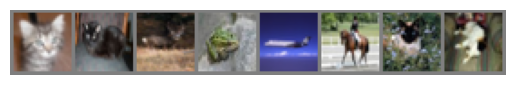

Соответствующие классы: cat   cat   deer  frog  airplane horse cat   cat  


In [5]:
def imshow(img):
    """Отображает изображение (тензор) после обратной нормализации."""
    img = img / 2 + 0.5  # Денормализация (mean=0.5, std=0.5)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Получаем один батч данных
data_iter = iter(train_loader)
images, labels = next(data_iter)

print("Пример батча из тренировочного набора:")
imshow(torchvision.utils.make_grid(images[:8]))
print("Соответствующие классы:", ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

## 5. Определение архитектуры (SimpleResNet)

Мы реализуем упрощенную версию знаменитой архитектуры **ResNet**. Ключевая идея ResNet — это **остаточные связи (residual connections или shortcuts)**. Они позволяют градиентам беспрепятственно проходить через множество слоев, что решает проблему затухания градиента и позволяет строить очень глубокие сети.

- **`BasicBlock`**: Содержит две свертки 3x3, батч-нормализацию и ReLU. Главное — это `shortcut`, который добавляет вход `x` к выходу блока.
- **`SimpleResNet`**: Собирает модель из нескольких слоев, каждый из которых состоит из нескольких `BasicBlock`.

In [6]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class SimpleResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(SimpleResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def SimpleResNet18(num_classes=10):
    return SimpleResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

## 6. Функции для обучения и оценки

### `train_and_validate`
Эта функция инкапсулирует весь цикл обучения.
- На каждой эпохе она сначала проходит по всем тренировочным данным (`model.train()`), вычисляет потери, делает обратное распространение ошибки и обновляет веса.
- Затем она переключается в режим оценки (`model.eval()`) и проходит по валидационным данным для измерения качества модели на "невиданных" данных.
- Реализована **ранняя остановка**: если потери на валидации не улучшаются в течение `patience` эпох, обучение прекращается, чтобы избежать переобучения. Лучшая модель сохраняется в файл.

### `evaluate`
Эта функция используется для финальной оценки на тестовом наборе. Она возвращает истинные метки и предсказания модели, которые мы затем используем для построения отчетов.

In [7]:
def train_and_validate(model, criterion, optimizer, train_loader, val_loader,
                       num_epochs, patience, device):
    """Тренировка модели с валидацией и ранней остановкой."""
    writer = SummaryWriter(log_dir='runs/hw_1')
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        epoch_val_acc = 100. * correct / total

        writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
        writer.add_scalar('Loss/Validation', epoch_val_loss, epoch)
        writer.add_scalar('Accuracy/Validation', epoch_val_acc, epoch)

        print(f"Эпоха [{epoch+1}/{num_epochs}], "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_acc:.2f}%")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print("Модель сохранена как лучшая.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Ранняя остановка сработала!")
                break
    
    writer.close()
    return train_losses, val_losses


def evaluate(model, test_loader, device):
    """Оценка модели на тестовом наборе данных."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

## 7. Запуск обучения

Здесь мы собираем всё вместе:
1.  Определяем устройство (`cuda` если доступен GPU, иначе `cpu`).
2.  Инициализируем нашу модель `SimpleResNet18`.
3.  Выбираем функцию потерь (`CrossEntropyLoss` для многоклассовой классификации) и оптимизатор (`Adam`).
4.  Запускаем функцию `train_and_validate`.
5.  После обучения загружаем веса лучшей модели, сохраненной в процессе.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используется устройство:", device)

model = SimpleResNet18(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, val_losses = train_and_validate(
    model, criterion, optimizer, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device
)

# Загружаем лучшую модель для финальной оценки
print("\nЗагрузка лучшей модели для оценки...")
model.load_state_dict(torch.load('best_model.pth'))

Используется устройство: cuda
Эпоха [1/20], Train Loss: 1.4288, Val Loss: 1.3250, Val Acc: 55.91%
Модель сохранена как лучшая.
Эпоха [2/20], Train Loss: 0.9551, Val Loss: 0.8366, Val Acc: 70.17%
Модель сохранена как лучшая.
Эпоха [3/20], Train Loss: 0.7426, Val Loss: 0.7643, Val Acc: 73.42%
Модель сохранена как лучшая.
Эпоха [4/20], Train Loss: 0.5844, Val Loss: 0.6134, Val Acc: 78.38%
Модель сохранена как лучшая.
Эпоха [5/20], Train Loss: 0.4611, Val Loss: 0.5936, Val Acc: 79.95%
Модель сохранена как лучшая.
Эпоха [6/20], Train Loss: 0.3630, Val Loss: 0.5786, Val Acc: 81.32%
Модель сохранена как лучшая.
Эпоха [7/20], Train Loss: 0.2722, Val Loss: 0.5861, Val Acc: 81.37%
Эпоха [8/20], Train Loss: 0.1894, Val Loss: 0.6040, Val Acc: 82.06%
Эпоха [9/20], Train Loss: 0.1425, Val Loss: 0.6223, Val Acc: 82.43%
Эпоха [10/20], Train Loss: 0.1001, Val Loss: 0.6754, Val Acc: 82.53%
Эпоха [11/20], Train Loss: 0.0897, Val Loss: 0.6835, Val Acc: 83.57%
Ранняя остановка сработала!

Загрузка лучшей м

<All keys matched successfully>

## 8. Анализ результатов на тестовой выборке

Теперь, когда модель обучена, мы оцениваем ее на тестовом наборе, который модель никогда не видела.

- **Classification Report**: Показывает метрики `precision`, `recall` и `f1-score` для каждого класса. Это помогает понять, какие классы модель распознает хорошо, а какие — плохо.
- **Confusion Matrix (Матрица ошибок)**: Визуализирует, какие классы модель путает между собой. Элемент на пересечении строки `i` и столбца `j` показывает, сколько объектов класса `i` были предсказаны как класс `j`. Идеальная матрица — диагональная.


Классификационный отчёт на тестовом наборе:
              precision    recall  f1-score   support

    airplane       0.83      0.85      0.84      1000
  automobile       0.94      0.91      0.92      1000
        bird       0.76      0.73      0.74      1000
         cat       0.59      0.72      0.65      1000
        deer       0.88      0.72      0.79      1000
         dog       0.61      0.83      0.70      1000
        frog       0.89      0.77      0.83      1000
       horse       0.94      0.73      0.82      1000
        ship       0.93      0.87      0.90      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



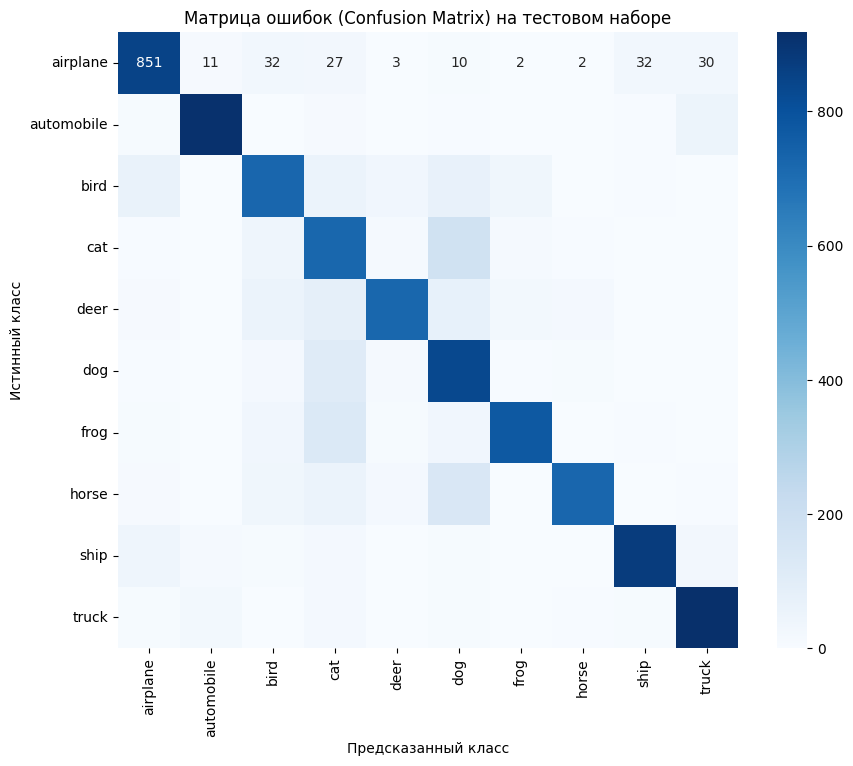

In [9]:
y_true, y_pred = evaluate(model, test_loader, device=device)

print("\nКлассификационный отчёт на тестовом наборе:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Матрица ошибок (Confusion Matrix) на тестовом наборе")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

### Выводы по матрице ошибок и отчёту:


*   **Сильные стороны:** Модель отлично распознает технику. Классы `automobile`, `ship` и `truck` имеют наивысшие F1-score (> 0.90), что говорит о высокой точности и полноте для этих категорий.

*   **Слабые стороны:** Основная проблема — различение визуально похожих животных. Наихудшие результаты у классов `cat` (F1: 0.65) и `dog` (F1: 0.70). Низкий `precision` (0.59-0.61) для этих классов указывает на то, что модель часто путает их между собой.

*   **Особенность:** Класс `horse` демонстрирует высокий `precision` (0.94), но низкий `recall` (0.73). Это означает, что если модель предсказывает "лошадь", она почти всегда права, однако при этом она пропускает около 27% реальных изображений лошадей, классифицируя их как что-то другое (вероятно, `deer` или `dog`).

## 9. Визуализация процесса обучения

Графики потерь на тренировочной и валидационной выборках — важный инструмент для диагностики.
- Если `Train Loss` падает, а `Validation Loss` растет, это явный признак **переобучения**.
- В идеале обе кривые должны сходиться к низкому значению. Ранняя остановка помогла нам остановиться в точке, где `Validation Loss` была минимальной.

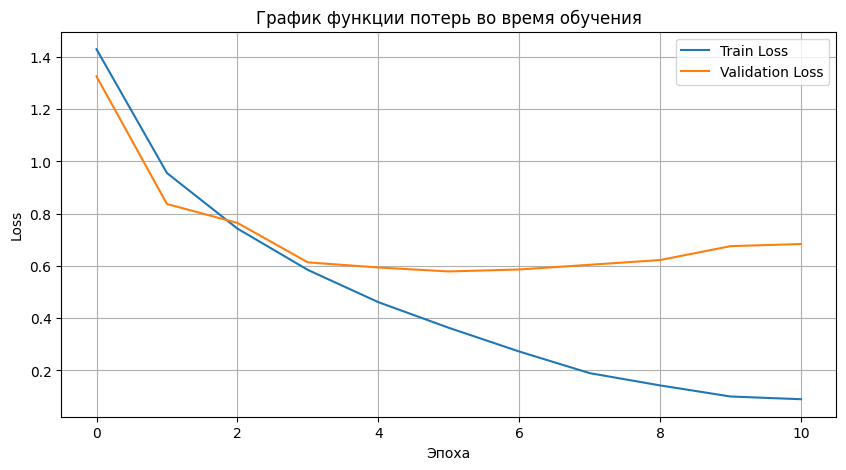

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("График функции потерь во время обучения")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 10. Демонстрация предсказаний

Наконец, давайте посмотрим на конкретные примеры из тестового набора и сравним предсказания модели с истинными метками. Это помогает получить интуитивное представление о том, как работает модель.

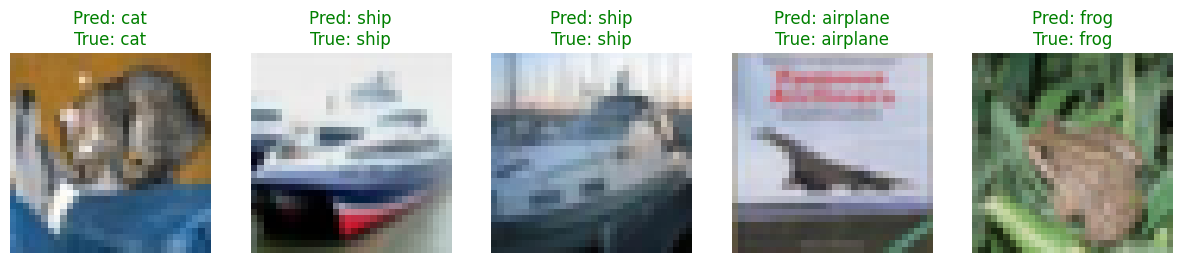

In [11]:
def show_predictions(model, loader, device, num_images=5):
    """Отображает предсказания модели на нескольких изображениях."""
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:num_images], labels[:num_images]

    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(15, 4))
    for idx in range(num_images):
        ax = plt.subplot(1, num_images, idx + 1)
        img = images[idx] / 2 + 0.5  # денормализация
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        
        # Цвет заголовка в зависимости от правильности предсказания
        color = "green" if predicted[idx] == labels[idx] else "red"
        
        plt.imshow(npimg)
        ax.set_title(f"Pred: {classes[predicted[idx]]}\nTrue: {classes[labels[idx]]}", color=color)
        plt.axis('off')
    plt.show()

show_predictions(model, test_loader, device=device, num_images=5)

### Итоговый вывод

Мы успешно реализовали и обучили нейронную сеть архитектуры ResNet-18 для задачи классификации изображений на датасете CIFAR-10. Модель показывает хорошие результаты, а инструменты анализа, такие как матрица ошибок и визуализация предсказаний, позволяют глубоко понять ее сильные и слабые стороны. Дальнейшие шаги по улучшению могут включать:
- Тюнинг гиперпараметров (скорость обучения, размер батча).
- Использование более сложных аугментаций.
- Обучение в течение большего количества эпох.
- Использование более сложной архитектуры (например, ResNet-34).